# Tutorial: Markov Random Fields (MRF) in aGrUM (C++)

Ported from the [pyAgrum notebook](../../wrappers/pyagrum/doc/sphinx/notebooks/23-Models_MarkovRandomField.ipynb). Same caveat as the other C++ tutorials here: each `%%cpp` cell is a standalone program, no state shared with the previous cell.

In [1]:
%load_ext gum_cppnb

## Building a Markov random field

`fastPrototype` uses a mini-language close to `BayesNet`'s, but cliques/factors are separated by `--` (double dash) instead of `->`:

MRF{nodes: 6, edges: 8, domainSize: 64, dim: 24}


[0]

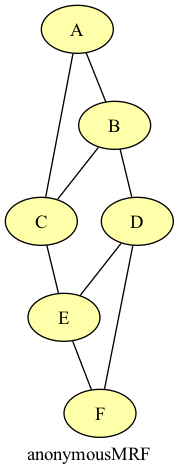

In [2]:
%%cpp
#include <agrum/mrf.h>

int main() {
  auto mn = gum::MarkovRandomField<double>::fastPrototype("A--B--C;B--D;C--E;D--E--F");
  std::cout << mn.toString() << std::endl;
  cppnb_add_dot(mn.toDot());
}

### Accessors

In [3]:
%%cpp
#include <agrum/mrf.h>

int main() {
  auto mn = gum::MarkovRandomField<double>::fastPrototype("A--B--C;B--D;C--E;D--E--F");

  std::cout << "size: " << mn.size() << ", edges: " << mn.sizeEdges() << std::endl;

  // no names()-equivalent in C++: iterate nodes() and read variable(n).name()
  for (const auto n : mn.nodes())
    std::cout << mn.variable(n).name() << " ";
  std::cout << std::endl;

  for (const auto& e : mn.edges())
    std::cout << "(" << mn.variable(e.first()).name() << ","
              << mn.variable(e.second()).name() << ") ";
  std::cout << std::endl;
}

size: 6, edges: 8
A B C D E F 
(A,B) (B,D) (D,F) (E,F) (A,C) (B,C) (C,E) (D,E) 


## Manipulating factors

Build an MRF node by node, declare cliques with `addFactor` (returns the factor `Tensor`, created on first call), fill it exactly like a BayesNet CPT:


      ║  A                │
B     ║0        │1        │
──────║─────────│─────────│
0     ║ 0.2000  │ 0.8000  │
1     ║ 0.6000  │ 0.4000  │



[0]

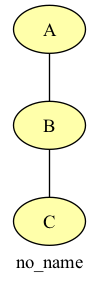

In [4]:
%%cpp
#include <agrum/mrf.h>

int main() {
  gum::MarkovRandomField<double> mn;
  mn.add("A", 2);
  mn.add("B", 2);
  mn.add("C", 2);

  mn.addFactor({"A", "B"}).fillWith({0.2, 0.8, 0.6, 0.4});
  mn.addFactor({"B", "C"}).fillWith({0.5, 0.5, 0.1, 0.9});

  std::cout << mn.factor({"A", "B"}) << std::endl;
  cppnb_add_dot(mn.toDot());
}

## From BayesNet to MarkovRandomField

BN : BN{nodes: 7, arcs: 7, domainSize: 128, dim: 19, mem: 304o}
MRF: MRF{nodes: 7, edges: 11, domainSize: 128, dim: 38}


[0],[1]

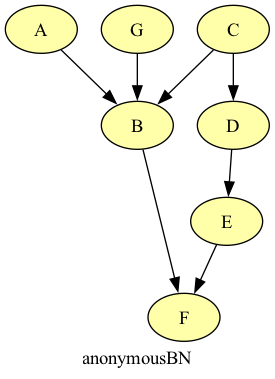
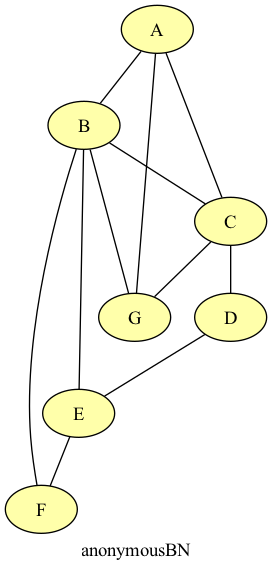

In [5]:
%%cpp
#include <agrum/mrf.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("A->B<-C->D->E->F<-B<-G");
  auto mn = gum::MarkovRandomField<double>::fromBN(bn);

  std::cout << "BN : " << bn.toString() << std::endl;
  std::cout << "MRF: " << mn.toString() << std::endl;
  cppnb_add_dot(bn.toDot());
  cppnb_add_dot(mn.toDot());
}

## Inference in a Markov random field

`ShaferShenoyMRFInference` mirrors `LazyPropagation`'s API (`addEvidence`, `makeInference`, `posterior`). Converting a BN to its moralized MRF and running inference on both must give the same marginals -- the MRF's factors are exactly the BN's CPTs, just stripped of their orientation.

In [6]:
%%cpp
#include <agrum/bn.h>
#include <agrum/BN/inference/lazyPropagation.h>
#include <agrum/mrf.h>

int main() {
  auto bn = gum::BayesNet<double>::fastPrototype("A->B<-C->D->E->F<-B<-G");
  bn.generateCPTs();

  gum::LazyPropagation iebn(&bn);
  iebn.addEvidence("D", 1);
  iebn.makeInference();

  auto mn = gum::MarkovRandomField<double>::fromBN(bn);
  gum::ShaferShenoyMRFInference iemn(&mn);
  iemn.addEvidence("D", 1);
  iemn.makeInference();

  std::cout << "P(A) via BN : " << iebn.posterior("A") << std::endl;
  std::cout << "P(A) via MRF: " << iemn.posterior("A") << std::endl;
}

P(A) via BN : 
  A                │
0        │1        │
─────────│─────────│
 0.4250  │ 0.5750  │

P(A) via MRF: 
  A                │
0        │1        │
─────────│─────────│
 0.4250  │ 0.5750  │

